In [ ]:
!pip install librosa noisereduce tqdm

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/LungData/metadata_segments.csv")
df.head()


,file_path,label_idx
0,/content/drive/MyDrive/LungData/ICBHI_Segments...,1
1,/content/drive/MyDrive/LungData/ICBHI_Segments...,1
2,/content/drive/MyDrive/LungData/ICBHI_Segments...,1
3,/content/drive/MyDrive/LungData/ICBHI_Segments...,1
4,/content/drive/MyDrive/LungData/ICBHI_Segments...,1


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_idx"]
)


In [ ]:
def extract_spectrogram(path):

    y, sr = librosa.load(path, sr=22050)
    y, _ = librosa.effects.trim(y)
    y = librosa.util.normalize(y)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        fmax=4000
    )

    log = librosa.power_to_db(mel, ref=np.max)

    log = (log - log.min()) / (log.max() - log.min())
    log = (log * 255).astype(np.uint8)

    img = Image.fromarray(log).convert("RGB")
    img = img.resize((224,224))

    return img


In [ ]:
class LungDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]["file_path"]
        label = self.df.iloc[idx]["label_idx"]

        img = extract_spectrogram(path)

        if self.transform:
            img = self.transform(img)

        return img, label


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


In [ ]:
train_dataset = LungDataset(train_df, transform)
test_dataset  = LungDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)


In [ ]:
counts = train_df["label_idx"].value_counts().sort_index()
weights = 1.0 / counts
weights = weights / weights.sum()

class_weights = torch.FloatTensor(weights.values).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)


In [ ]:
resnet50 = models.resnet50(pretrained=True)
resnet50.fc = nn.Identity()
resnet50 = resnet50.to(device)

for p in resnet50.parameters():
    p.requires_grad = False


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 309MB/s]


In [ ]:
resnet34 = models.resnet34(pretrained=True)
resnet34.fc = nn.Identity()
resnet34 = resnet34.to(device)

for p in resnet34.parameters():
    p.requires_grad = False

for p in resnet34.layer4.parameters():
    p.requires_grad = True


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 342MB/s]


In [ ]:
class CascadeHybrid(nn.Module):
    def __init__(self):
        super().__init__()

        self.m1 = resnet50
        self.m2 = resnet34

        self.classifier = nn.Sequential(
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,4)
        )

    def forward(self,x):

        f1 = self.m1(x)
        f2 = self.m2(x)

        return self.classifier(f2)


In [ ]:
model = CascadeHybrid().to(device)


In [ ]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


In [ ]:
def train(model, loader, epochs=10):

    model.train()

    for epoch in range(epochs):

        correct,total,loss_sum = 0,0,0

        for x,y in tqdm(loader):

            x,y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out,y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)

        print("Epoch",epoch+1,
              "Loss:",loss_sum/len(loader),
              "Acc:",100*correct/total)


In [ ]:
train(model, train_loader, epochs=15)


100%|██████████| 347/347 [43:08<00:00,  7.46s/it]


Epoch 1 Loss: 1.2513634596846632 Acc: 40.67399531447108


100%|██████████| 347/347 [03:09<00:00,  1.84it/s]


Epoch 2 Loss: 0.9429271885915861 Acc: 61.00198233916021


100%|██████████| 347/347 [03:13<00:00,  1.79it/s]


...

Epoch 13 Loss: 0.07005362048435161 Acc: 97.31483150117138


100%|██████████| 347/347 [03:09<00:00,  1.83it/s]


Epoch 14 Loss: 0.09314481684567691 Acc: 96.43178951162372


100%|██████████| 347/347 [03:07<00:00,  1.85it/s]

Epoch 15 Loss: 0.07890034171749948 Acc: 97.3328527662642


In [ ]:
def evaluate(model, loader):

    model.eval()
    correct,total = 0,0

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)

    print("Final Accuracy:",100*correct/total)

evaluate(model,test_loader)


Final Accuracy: 67.93948126801153


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
def get_predictions(model, loader):

    model.eval()
    preds = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)
            pred = out.argmax(1).cpu().numpy()

            preds.extend(pred)
            labels.extend(y.numpy())

    return np.array(preds), np.array(labels)


In [ ]:
preds, labels = get_predictions(model, test_loader)

cm = confusion_matrix(labels, preds)
cm


array([[258,  76,  66,  26],
       [ 13, 151,  10,  24],
       [ 42,  33, 357,  27],
       [ 28,  39,  61, 177]])

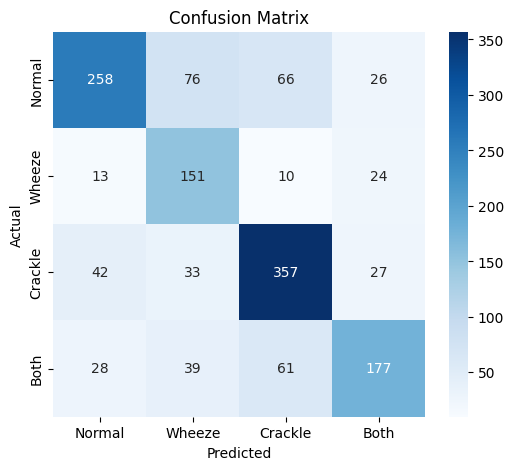

In [ ]:
class_names = ["Normal","Wheeze","Crackle","Both"]

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print(classification_report(labels, preds, target_names=class_names))


              precision    recall  f1-score   support

      Normal       0.76      0.61      0.67       426
      Wheeze       0.51      0.76      0.61       198
     Crackle       0.72      0.78      0.75       459
        Both       0.70      0.58      0.63       305

    accuracy                           0.68      1388
   macro avg       0.67      0.68      0.67      1388
weighted avg       0.70      0.68      0.68      1388

